In [24]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np



numeric_columns = ["device_age_months", "battery_capacity_mah"]

data  = pd.read_excel("clean_data.xlsx")
my_columns = numeric_columns


In [19]:
print("Missing Values")
missing = data[my_columns].isnull().sum()
print(missing)
if missing.sum() == 0:
    print("\nNo missing values.")
else:
    pct_missing = (missing / len(data) * 100).round(2)
    print("\nPercent missing:")
    print(pct_missing)

print("\nData Types")
print(data[my_columns].dtypes)

print("\nSummary Stats (numeric columns)")
print(data[numeric_columns].describe())

Missing Values
device_age_months       0
battery_capacity_mah    0
dtype: int64

No missing values.

Data Types
device_age_months       int64
battery_capacity_mah    int64
dtype: object

Summary Stats (numeric columns)
       device_age_months  battery_capacity_mah
count        5000.000000           5000.000000
mean           24.232400           4134.700000
std            14.138004            745.061698
min             0.000000           3000.000000
25%            12.000000           4000.000000
50%            24.000000           4500.000000
75%            36.000000           5000.000000
max            48.000000           5000.000000


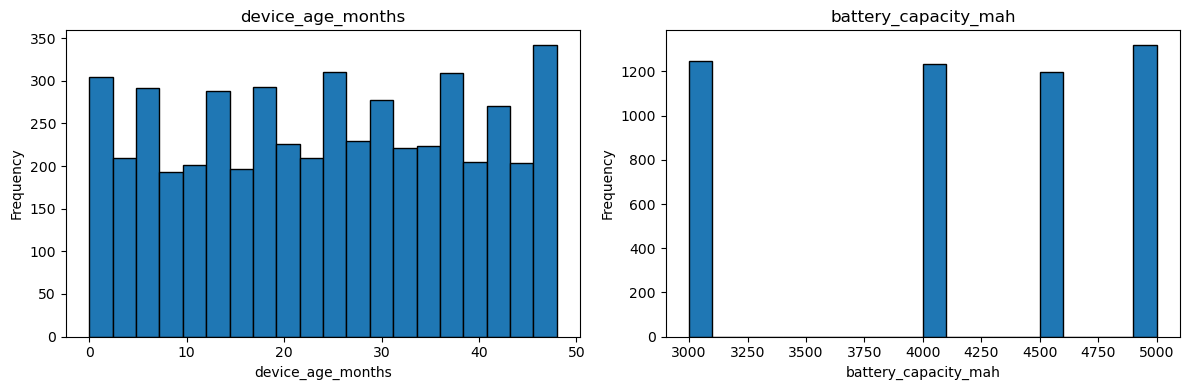

In [21]:
if numeric_columns:
    n = len(numeric_columns)
    nrows = (n + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(12, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_columns):
        axes[i].hist(data[col], bins=20, edgecolor="black")
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

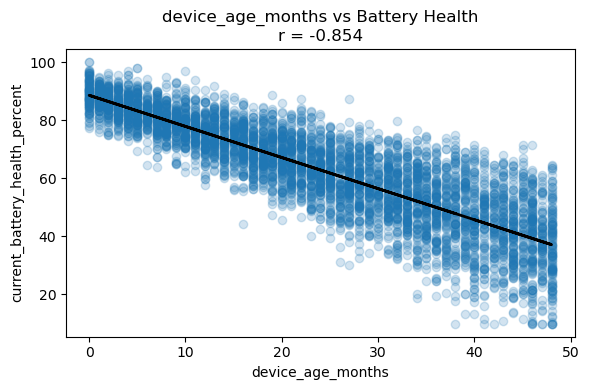

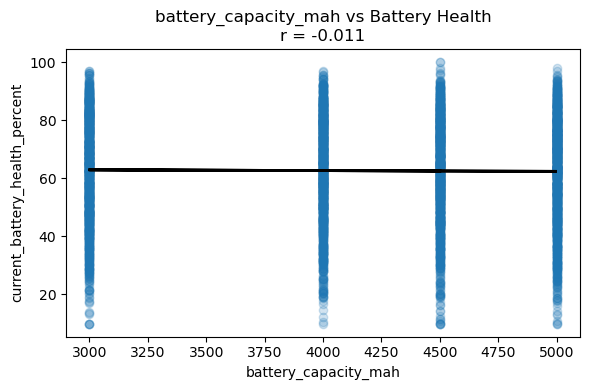

In [25]:
target = "current_battery_health_percent"

for col in numeric_columns:
    x = data[col]
    y = data[target]

    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.2)

    r = x.corr(y)

    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, color="black", linewidth=2)

    plt.title(f"{col} vs Battery Health\nr = {r:.3f}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()